### Train Preprocess Pipeline

### 1. Set Kernel Env

In [1]:
# %%bash

# PKGs=$(
#     /opt/conda/envs/python3.9.25_spark_scrach_kernel/bin/pip3 list -v \
#     | grep "/home/$USER/.local/lib/python.*/site-packages" \
#     | awk '{printf "%s==%s ", $1, $2}'
# ) && \
# echo "%pip uninstall -y $PKGs"

In [2]:
# %pip install -e /home/gorelova_i_v/projects/cvm_churn-from-dac_binary-class_churn-dac

In [39]:
%load_ext autoreload
%load_ext dotenv
%dotenv
%autoreload 2

from IPython.display import display

import logging
logger = logging.getLogger()
logger.setLevel(logging.INFO)

from datetime import datetime, timedelta
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path(os.getenv('PROJECT_ROOT_PATH'))

SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import seaborn as sns
import phik

from cvm_model.io import State
import cvm_model.utils as utils
import cvm_model.sql as sql

from cvm_model.preprocess import _prepare_dataset, _validate_dataset
from cvm_model.parameters import (
    SAMPLE_SIZE,
    RANDOM_STATE,
    HOLDOUT_SIZE,
    features_for_outliers,
    aud_table,
    fav_omni_features_table,
    preperiod_months,
    target,
    input_suffix,
)

from sklearn.model_selection import train_test_split


### 2. State and Connections

In [40]:
try:
    spark.stop()
except NameError:
    pass

state = State.from_env()
engine = state.credentials.loyalty_gp.sa_engine
s3 = state.credentials.cvm_s3
print('State loaded')


### 3. Set Event Timestamp

In [41]:
event_timestamp = datetime(2026, 2, 1)

In [42]:
train_timestamp = event_timestamp - timedelta(weeks=4)

base_month = train_timestamp.date().replace(day=1).isoformat()
target_month = (pd.Timestamp(base_month) + pd.DateOffset(months=1)).date().isoformat()
feature_date = target_month

base_month, target_month, feature_date


('2026-02-01', '2026-03-01', '2026-03-01')

### 4. Resolve S3 Input Path

In [8]:
input_prefix = state.settings.preprocess_prefix(event_timestamp) / input_suffix
input_bucket = input_prefix.split('//')[1].split('/')[0]

utils.remove_s3_prefix(s3, input_bucket, input_prefix)
assert not utils.list_s3_objects(s3, input_bucket, input_prefix), 'S3 input prefix was not cleaned'

input_prefix, input_bucket


('cvm-current-customer-data',
 'ml_platform/churn/cvm_churn-from-dac_binary-class_churn-dac/temporary_1/2026-02-01/input',
 's3a://cvm-current-customer-data/ml_platform/churn/cvm_churn-from-dac_binary-class_churn-dac/temporary_1/2026-02-01/input')

### 5. Audience Table

Аудиторией являются пользователи, которые имеют статус DAC в `base_month`, определяемый
по `event_timestamp`.


При этом статус DAC определяется актуальной бизнес-логикой:

```SQL
   has_transaction_activity = 1
   and (
       has_mobapp_activity = 1
       or has_pwa_activity = 1
       or vcoff_trn_cnt > 0
       )
```

Для EDA и базового анализа фичей принимается случайная подвыборка из суммарной аудитории DAC в `base_month`.

In [9]:
sample_aud_query = sql.aud_query + f' order by random() limit {SAMPLE_SIZE}'


In [10]:
df = utils.get_df(engine, sample_aud_query.format(base_month=base_month))
df = df.astype({col: np.int32 for col in {'contact_id'} & set(df.columns)})

assert len(df) > 0, 'No DAC audience contacts were loaded'
assert df['contact_id'].is_unique, 'DAC audience contains duplicate contact_id values'

utils.upload_df(engine, pd.DataFrame(df['contact_id']).astype(int), aud_table)
print('Audience shape:', df.shape)


INFO:root:trying to load using csv: table_name: cvm_sbx.cvm_churn_from_dac_binary_class_churn_dac_aud; total_size_mb: 38.15; total_rows: 10_000_000; bytes_per_row 4.00; rows_per_batch: 26_214_316...
INFO:root:loading batch: 00000...
INFO:root:done loading into: cvm_sbx.cvm_churn_from_dac_binary_class_churn_dac_aud


In [11]:
aud_query = f'select distinct contact_id :: int as contact_id from {aud_table}'
df = utils.get_df(engine, aud_query)
print(df.shape)


(10000000, 1)


### 5. Target Feature

`target_churn_from_dac = 1` - клиент был DAC в базовом месяце и не DAC в следующем.

In [12]:
query_kwargs = dict(
    aud=aud_query,
    target_month=target_month,
)

df_part = utils.get_df(engine, sql.target_query.format(**query_kwargs))
cast_cols = {target} & set(df_part.columns)
df_part = df_part.astype({col: np.int32 for col in cast_cols})

assert df_part['contact_id'].is_unique, 'target_query returned duplicate contact_id values'

df = df.merge(df_part, on='contact_id', how='inner')
assert len(df) > 0, 'Dataset is empty after target labeling'

utils.upload_df(engine, pd.DataFrame(df['contact_id']).astype(int), aud_table)
aud_query = f'select distinct contact_id :: int as contact_id from {aud_table}'

print('After target:', df.shape)
print('Target rate:', df[target].mean())


After target: (10000000, 2)


### 6. Load all Features

In [13]:
df = utils.load_features(
    engine=engine,
    df=df,
    aud_query=aud_query,
    date=feature_date,
    fav_omni_features_table=fav_omni_features_table,
    preperiod_months=preperiod_months,
)


INFO:root:Loading recency features...
INFO:root:Loading perf recency features...
INFO:root:Creating favourite OMNI features temp table...
INFO:root:Выгружаем Чеки за 24 мес...
INFO:root:Adding 16 columns to dataset. New total columns: 23
INFO:root:Выгружаем Чеки (сокращ.) за 12 мес...
INFO:root:Adding 4 columns to dataset. New total columns: 27
INFO:root:Выгружаем Чеки (сокращ.) за 6 мес...
INFO:root:Adding 4 columns to dataset. New total columns: 31
INFO:root:Выгружаем Чеки (сокращ.) за 3 мес...
INFO:root:Adding 4 columns to dataset. New total columns: 35
INFO:root:Выгружаем Чеки (сокращ.) за 2 мес...
INFO:root:Adding 4 columns to dataset. New total columns: 39
INFO:root:Выгружаем Чеки (сокращ.) за 1 мес...
INFO:root:Adding 4 columns to dataset. New total columns: 43
INFO:root:Выгружаем Логины за 24 мес...
INFO:root:Adding 2 columns to dataset. New total columns: 45
INFO:root:Выгружаем Логины за 12 мес...
INFO:root:Adding 2 columns to dataset. New total columns: 47
INFO:root:Выгружаем

In [16]:
df = _prepare_dataset(df)
_validate_dataset(df, 'full_dataset')

df.to_parquet(f'df_raw_{base_month}.parquet', index=False)
print('Prepared raw dataset:', df.shape)


### 12. Target Distribution

In [43]:
df = pd.read_parquet(f'df_raw_{base_month}.parquet')

In [44]:
numeric_features = [f for f in df.columns if pd.api.types.is_numeric_dtype(df[f])]
eda_df = df[numeric_features].copy()

target_counts = df[target].value_counts(dropna=False).sort_index()
target_share = df[target].value_counts(normalize=True, dropna=False).sort_index()
target_report = pd.concat([target_counts.rename('cnt'), target_share.rename('share')], axis=1)

display(target_report)
print('df shape:', df.shape)
print('numeric features:', len(numeric_features))
print('target:', target)

,cnt,share
0,8712523,0.87
1,1287477,0.13


df shape: (10000000, 159)
numeric features: 159
target: target_churn_from_dac


### 13. Missing, Zero And Basic Stats

In [45]:
eda_report = pd.DataFrame(index=numeric_features)

eda_report['dtype'] = df[numeric_features].dtypes.astype(str)
eda_report['missing_share'] = df[numeric_features].isna().mean()
eda_report['zero_share'] = (df[numeric_features] == 0).mean()
eda_report['nunique'] = df[numeric_features].nunique(dropna=True)
eda_report['mean'] = df[numeric_features].mean(numeric_only=True)
eda_report['std'] = df[numeric_features].std(numeric_only=True)
eda_report['p01'] = df[numeric_features].quantile(0.01, numeric_only=True)
eda_report['p50'] = df[numeric_features].quantile(0.50, numeric_only=True)
eda_report['p99'] = df[numeric_features].quantile(0.99, numeric_only=True)

display(eda_report.sort_values(['missing_share', 'zero_share'], ascending=False))

,dtype,missing_share,zero_share,nunique,mean,std,p01,p50,p99
omni_features_lag_avg_1,float64,0.73,0.04,897,3.88,4.41,0.00,2.50,22.00
omni_features_lag_avg_2,float64,0.61,0.03,2638,8.75,9.76,0.00,5.20,44.00
omni_features_lag_avg_3,float64,0.51,0.03,5333,11.52,13.20,0.00,6.89,64.00
omni_qr_lag_avg_1,float64,0.45,0.00,230,5.56,4.22,1.00,4.25,22.00
omni_features_lag_avg_6,float64,0.40,0.03,17967,17.87,22.20,0.00,10.57,117.00
...,...,...,...,...,...,...,...,...,...
dac_months_last_3,int64,0.00,0.00,3,2.68,0.63,1.00,3.00,3.00
dac_months_last_6,int64,0.00,0.00,6,4.95,1.54,1.00,6.00,6.00
dac_months_last_12,int64,0.00,0.00,12,8.90,3.59,1.00,11.00,12.00
dac_months_per_dac_age_ratio,float64,0.00,0.00,749,0.81,0.23,0.14,0.90,1.00


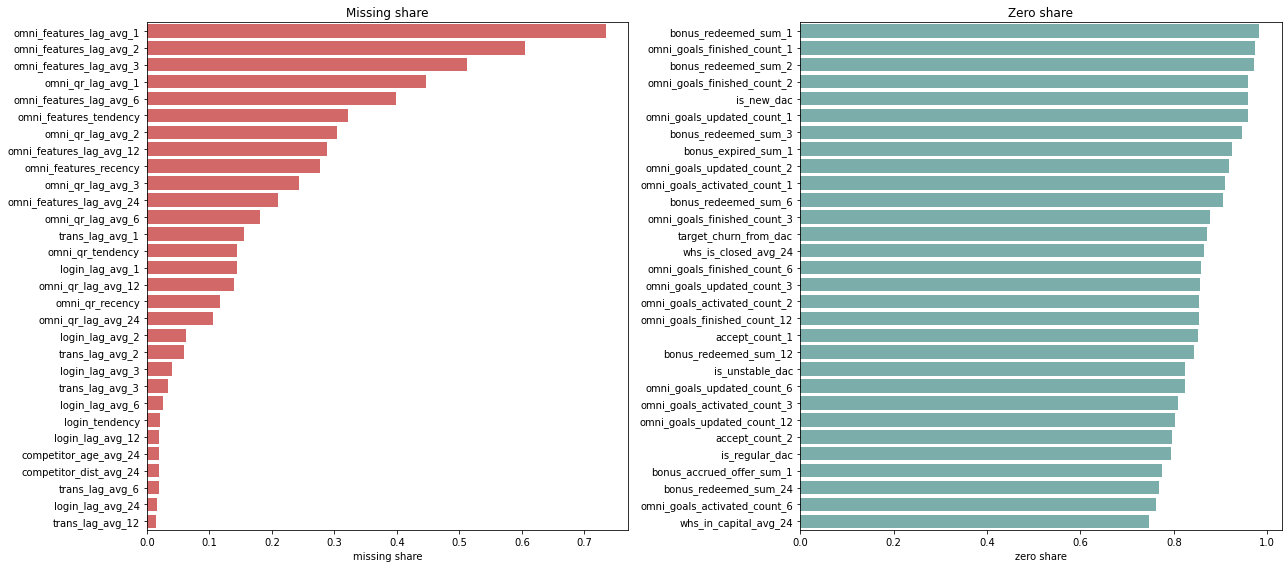

In [46]:
plot_report = eda_report.sort_values('missing_share', ascending=False).head(30).reset_index(names='feature')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
sns.barplot(data=plot_report, y='feature', x='missing_share', ax=axes[0], color='#E45756')
axes[0].set_title('Missing share')
axes[0].set_xlabel('missing share')
axes[0].set_ylabel('')

plot_zero = eda_report.sort_values('zero_share', ascending=False).head(30).reset_index(names='feature')
sns.barplot(data=plot_zero, y='feature', x='zero_share', ax=axes[1], color='#72B7B2')
axes[1].set_title('Zero share')
axes[1].set_xlabel('zero share')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [47]:
recency_cols = ['cheque_recency', 'login_recency', 'omni_qr_recency', 'omni_features_recency', 'perf_recency']
for col in recency_cols:
    if col in df.columns:
        df[col] = df[col].fillna(999)

### 14. DAC Segments

In [48]:
def dac_segment(row):
    if row.get('is_stable_dac', 0) == 1:
        return 'stable_10_12m'
    if row.get('is_regular_dac', 0) == 1:
        return 'regular_6_9m'
    if row.get('is_unstable_dac', 0) == 1:
        return 'unstable_2_5m'
    if row.get('is_new_dac', 0) == 1:
        return 'new_1m'
    return 'no_history'

df['dac_segment_12m'] = df.apply(dac_segment, axis=1)

segment_report = (
    df.groupby('dac_segment_12m', dropna=False)
    .agg(
        cnt=(target, 'size'),
        target_rate=(target, 'mean'),
        dac_months_last_12_mean=('dac_months_last_12', 'mean'),
    )
    .sort_values('target_rate', ascending=False)
)

if 'dac_segment_12m' in df.columns:
    df['segment'] = df['dac_segment_12m'].astype(str)

In [49]:
df['strat'] = df['segment'].astype(str) + '_' + df[target].astype(str)

strat_counts = df['strat'].value_counts()
if (strat_counts < 5).any():
    df['strat'] = df[target].astype(str)

display(df.groupby('segment')[target].agg(['count', 'mean']).sort_values('mean', ascending=False))


,count,mean
segment,,
new_1m,416711,0.40
unstable_2_5m,1754143,0.27
regular_6_9m,2059700,0.19
stable_10_12m,5769446,0.05


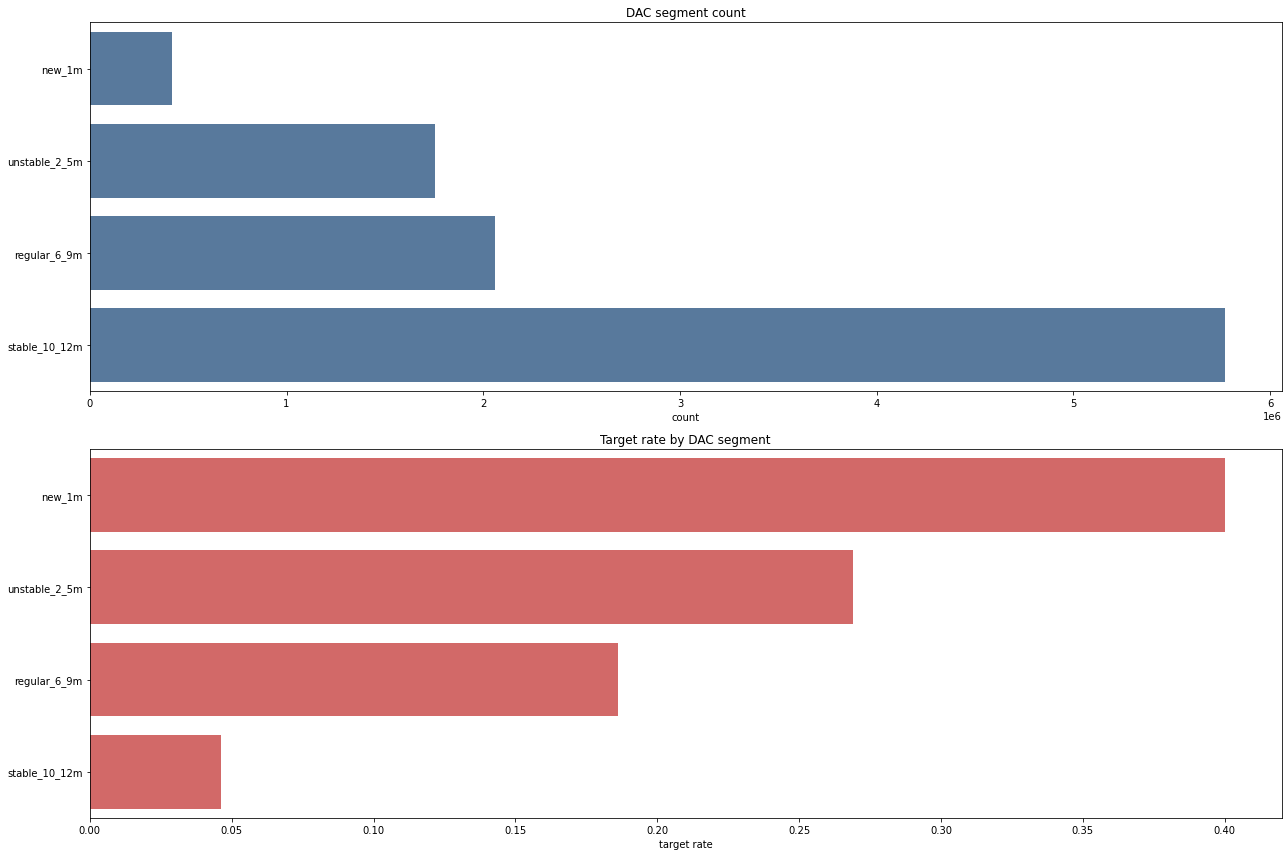

In [50]:
fig, axes = plt.subplots(2, 1, figsize=(18, 12))

sns.countplot(data=df, y='dac_segment_12m', order=segment_report.index, ax=axes[0], color='#4C78A8')
axes[0].set_title('DAC segment count')
axes[0].set_xlabel('count')
axes[0].set_ylabel('')

sns.barplot(data=segment_report.reset_index(), y='dac_segment_12m', x='target_rate', ax=axes[1], color='#E45756')
axes[1].set_title('Target rate by DAC segment')
axes[1].set_xlabel('target rate')
axes[1].set_ylabel('')


plt.tight_layout()
plt.show()

### 15. Correlation Matrix (Phik & Spearman)

In [12]:
phik_sample_n = min(len(eda_df), 10_000)
phik_df = eda_df.sample(phik_sample_n, random_state=42) if len(eda_df) > phik_sample_n else eda_df.copy()

phik_cols = [c for c in phik_df.columns if phik_df[c].notna().sum() > 0 and phik_df[c].nunique(dropna=True) > 1]
phik_df = phik_df[phik_cols]
interval_cols = [c for c in phik_cols if c != target]

phik_matrix = phik_df.phik_matrix(interval_cols=interval_cols)

phik_target = (
    phik_matrix[target]
    .drop(target, errors='ignore')
    .sort_values(ascending=False)
)

In [13]:
display(phik_target.to_frame('phik_with_target').head(15))

,phik_with_target
dac_months_last_6,0.506855
is_stable_dac,0.448662
dac_share_last_12,0.432455
dac_months_last_12,0.432455
login_count_3,0.397988
login_count_2,0.392553
login_lag_avg_6,0.384908
login_lag_avg_3,0.382394
login_count_1,0.371727
login_count_12,0.367328


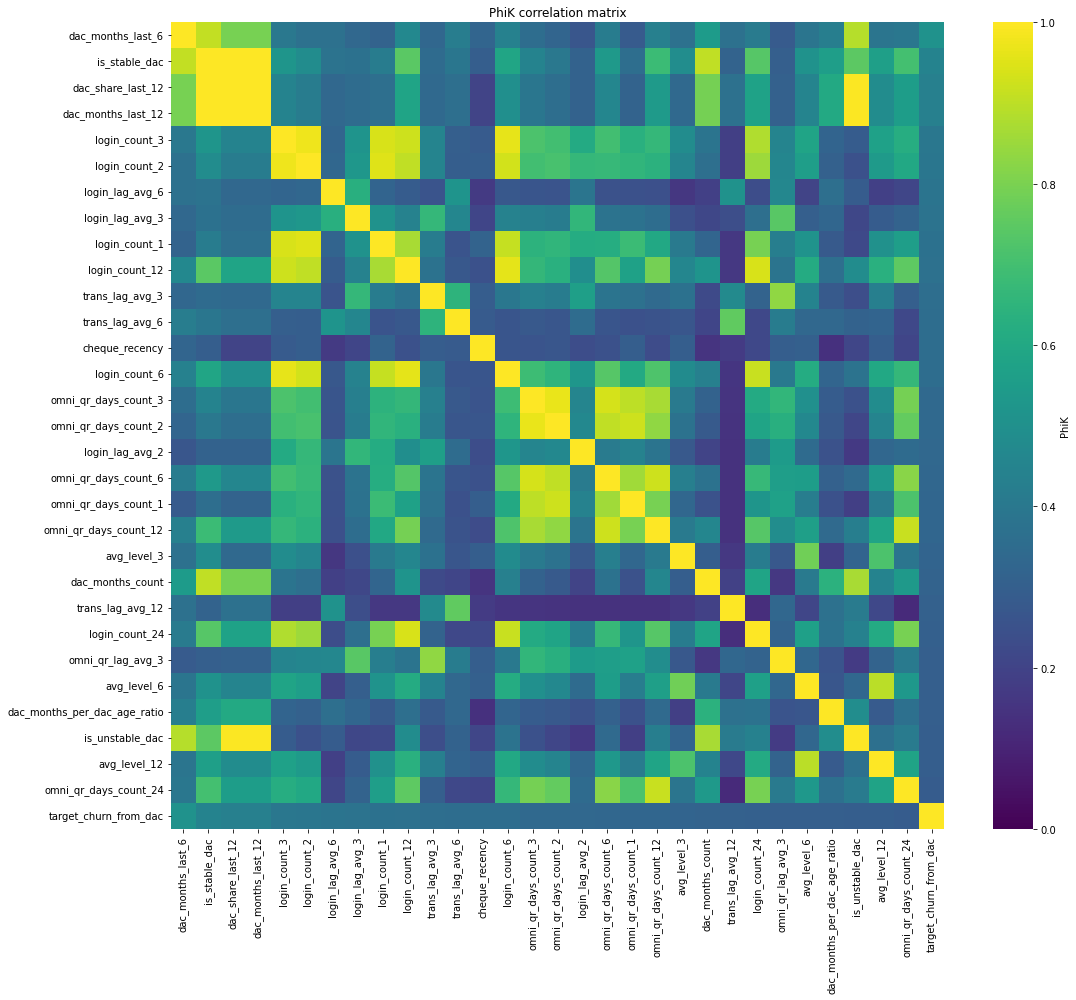

In [14]:
top_phik_features = phik_target.head(30).index.tolist()
heatmap_cols = top_phik_features + [target]

plt.figure(figsize=(16, 14))
sns.heatmap(
    phik_matrix.loc[heatmap_cols, heatmap_cols],
    cmap='viridis',
    vmin=0,
    vmax=1,
    square=False,
    cbar_kws={'label': 'PhiK'},
)
plt.title('PhiK correlation matrix')
plt.tight_layout()
plt.show()

In [ ]:
pearson_target = (
    eda_df.corr(method='pearson', numeric_only=True)[target]
    .drop(target)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
spearman_target = (
    eda_df.corr(method='spearman', numeric_only=True)[target]
    .drop(target)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

corr_target_report = pd.concat(
    [pearson_target.rename('pearson'), spearman_target.rename('spearman'), phik_target.rename('phik')],
    axis=1,
).sort_values('phik', ascending=False)

In [ ]:
display(corr_target_report.head(15))

,pearson,spearman,phik
dac_months_last_6,-0.368772,-0.369208,0.491797
is_stable_dac,-0.305507,-0.305507,0.428537
dac_months_last_12,-0.335969,-0.340310,0.409019
dac_share_last_12,-0.335969,-0.340310,0.409019
trans_lag_avg_3,0.265057,0.246902,0.381424
trans_lag_avg_6,0.298113,0.289237,0.381289
login_lag_avg_3,0.295470,0.295076,0.378666
omni_qr_days_count_2,-0.261739,-0.319761,0.375864
omni_qr_days_count_6,-0.261964,-0.335525,0.371909
omni_qr_days_count_3,-0.259395,-0.326462,0.370111


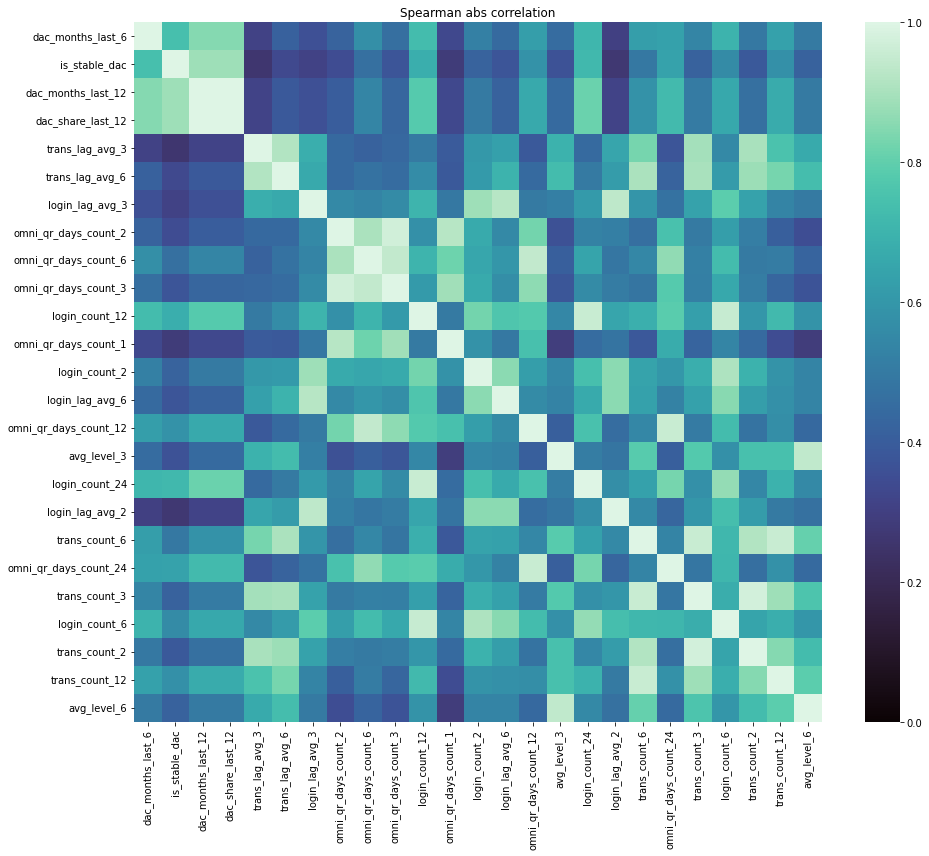

In [ ]:
top_corr_features = corr_target_report.head(25).index.tolist()
corr_for_heatmap = eda_df[top_corr_features].corr(method='spearman', numeric_only=True).abs()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_for_heatmap, cmap='mako', vmin=0, vmax=1)
plt.title('Spearman abs correlation')
plt.tight_layout()
plt.show()

upper = corr_for_heatmap.where(np.triu(np.ones(corr_for_heatmap.shape), k=1).astype(bool))
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'spearman_abs_corr'})
    .sort_values('spearman_abs_corr', ascending=False)
)

In [ ]:
display(high_corr_pairs[high_corr_pairs['spearman_abs_corr'] >= 0.80].head(15))

,feature_1,feature_2,spearman_abs_corr
47,dac_months_last_12,dac_share_last_12,1.000000
291,trans_count_3,trans_count_2,0.975521
148,omni_qr_days_count_2,omni_qr_days_count_3,0.971968
283,trans_count_6,trans_count_12,0.954291
280,trans_count_6,trans_count_3,0.954055
249,omni_qr_days_count_12,omni_qr_days_count_24,0.953725
200,login_count_12,login_count_24,0.953512
205,login_count_12,login_count_6,0.950290
169,omni_qr_days_count_6,omni_qr_days_count_12,0.943075
164,omni_qr_days_count_6,omni_qr_days_count_3,0.942250


### 16. Outliers

In [51]:
q = 0.999
df['outlier'] = 0

for f in features_for_outliers:
    if f not in df.columns or df[f].notna().sum() == 0:
        continue
    t = np.nanquantile(df[f], q)
    df.loc[df[f] > t, 'outlier'] = 1

outlier_share = len(df[df['outlier'] == 1]) / len(df)
outlier_share

0.0038109

In [52]:
assert outlier_share <= 0.01, 'Удалено как выбросы более 1% аудитории.'

df = df[df['outlier'] == 0].reset_index(drop=True)
df = df.drop(columns=['outlier'])

df.shape

(9961891, 162)

### 17. Feature Selection

In [ ]:
drop_manual = {'contact_id', target, 'is_dac_next_month', 'outlier', 'dac_share_last_12'}

available_features = [f for f in df.columns if f not in drop_manual]

feature_rank = corr_target_report.copy()
feature_rank['score_abs'] = feature_rank[['pearson', 'spearman', 'phik']].abs().max(axis=1)
feature_rank = feature_rank.sort_values('score_abs', ascending=False)

feature_quality = pd.DataFrame(index=available_features)
feature_quality['missing_share'] = df[available_features].isna().mean()
feature_quality['nunique'] = df[available_features].nunique(dropna=True)

feature_selection_report = (feature_rank.join(feature_quality, how='left').sort_values('score_abs', ascending=False))

selected_features = feature_selection_report[
(feature_selection_report['missing_share'] < 0.80)
    & (feature_selection_report['nunique'] > 1)
].index.tolist()

In [ ]:
TOP_N = 100

selected_features = selected_features[:TOP_N]

print('Available features:', len(available_features))
print('Selected features:', len(selected_features))

Available features: 157
Selected features: 100


,selected_features
0,dac_months_last_6
1,is_stable_dac
2,dac_months_last_12
3,login_count_3
4,login_count_6
5,trans_lag_avg_3
6,trans_lag_avg_6
7,login_count_2
8,login_lag_avg_3
9,omni_qr_days_count_2


### 18. Save Dataset

In [53]:
train_df, holdout_df = train_test_split(
    df,
    test_size=HOLDOUT_SIZE,
    random_state=RANDOM_STATE,
    stratify=df[target],
)

train_df = train_df.reset_index(drop=True)
holdout_df = holdout_df.reset_index(drop=True)

overlap = set(train_df['contact_id']) & set(holdout_df['contact_id'])
assert len(overlap) == 0, 'Train and holdout contact_id overlap'

_validate_dataset(train_df, 'train')
_validate_dataset(holdout_df, 'holdout')

utils.save_df_to_s3(train_df, s3, input_bucket, f'{input_prefix}/train')
utils.save_df_to_s3(holdout_df, s3, input_bucket, f'{input_prefix}/holdout')

train_path = f'train_{base_month}.parquet'
holdout_path = f'holdout_{base_month}.parquet'

train_df.to_parquet(train_path, index=False)
holdout_df.to_parquet(holdout_path, index=False)

print('Train shape:', train_df.shape)
print('Holdout shape:', holdout_df.shape)
print('Saved to S3:', f'{input_prefix}/train', f'{input_prefix}/holdout')
print('Saved locally:', train_path, holdout_path)

print('\nTrain target distribution:')
display(train_df[target].value_counts(normalize=True).to_frame('share'))

print('\nHoldout target distribution:')
display(holdout_df[target].value_counts(normalize=True).to_frame('share'))


Dataset shape: (9961891, 162)

Target distribution:


,share
0,0.87
1,0.13
